# Intelligent Home Security Machine Learning Techniques for Fault Detection in IoT Networks

In [1]:
# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
import joblib
import os
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [2]:
# Importing Dataset

In [3]:
dataset=pd.read_csv("Dataset.csv")

In [4]:
dataset

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,serror_rate,rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,attack
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.0,0.0,1.00,0.00,0.00,150,25,0.17,0.03,No
1,0,udp,other,SF,146,0,0,0,0,0,...,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,No
2,0,tcp,private,S0,0,0,0,0,0,0,...,1.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,Yes
3,0,tcp,http,SF,232,8153,0,0,0,0,...,0.2,0.0,1.00,0.00,0.00,30,255,1.00,0.00,No
4,0,tcp,http,SF,199,420,0,0,0,0,...,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148512,0,tcp,smtp,SF,794,333,0,0,0,0,...,0.0,0.0,1.00,0.00,0.00,100,141,0.72,0.06,No
148513,0,tcp,http,SF,317,938,0,0,0,0,...,0.0,0.0,1.00,0.00,0.18,197,255,1.00,0.00,No
148514,0,tcp,http,SF,54540,8314,0,0,0,2,...,0.0,0.0,1.00,0.00,0.20,255,255,1.00,0.00,Yes
148515,0,udp,domain_u,SF,42,42,0,0,0,0,...,0.0,0.0,1.00,0.00,0.33,255,252,0.99,0.01,No


In [5]:
dataset.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,serror_rate,rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,attack
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.0,0.0,1.00,0.00,0.00,150,25,0.17,0.03,No
1,0,udp,other,SF,146,0,0,0,0,0,...,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,No
2,0,tcp,private,S0,0,0,0,0,0,0,...,1.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,Yes
3,0,tcp,http,SF,232,8153,0,0,0,0,...,0.2,0.0,1.00,0.00,0.00,30,255,1.00,0.00,No
4,0,tcp,http,SF,199,420,0,0,0,0,...,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,No


In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148517 entries, 0 to 148516
Data columns (total 24 columns):
duration                  148517 non-null int64
protocol_type             148517 non-null object
service                   148517 non-null object
flag                      148517 non-null object
src_bytes                 148517 non-null int64
dst_bytes                 148517 non-null int64
land                      148517 non-null int64
wrong_fragment            148517 non-null int64
urgent                    148517 non-null int64
hot                       148517 non-null int64
logged_in                 148517 non-null int64
num_compromised           148517 non-null int64
count                     148517 non-null int64
srv_count                 148517 non-null int64
serror_rate               148517 non-null float64
rerror_rate               148517 non-null float64
same_srv_rate             148517 non-null float64
diff_srv_rate             148517 non-null float64
srv_diff_host_

In [7]:
dataset.isnull().sum()

duration                  0
protocol_type             0
service                   0
flag                      0
src_bytes                 0
dst_bytes                 0
land                      0
wrong_fragment            0
urgent                    0
hot                       0
logged_in                 0
num_compromised           0
count                     0
srv_count                 0
serror_rate               0
rerror_rate               0
same_srv_rate             0
diff_srv_rate             0
srv_diff_host_rate        0
dst_host_count            0
dst_host_srv_count        0
dst_host_same_srv_rate    0
dst_host_diff_srv_rate    0
attack                    0
dtype: int64

In [8]:
dataset.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,logged_in,num_compromised,count,srv_count,serror_rate,rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate
count,148517.000000,1.485170e+05,1.485170e+05,148517.000000,148517.000000,148517.000000,148517.000000,148517.000000,148517.000000,148517.000000,148517.000000,148517.000000,148517.000000,148517.000000,148517.000000,148517.000000,148517.000000,148517.000000,148517.000000,148517.000000
mean,276.779305,4.022795e+04,1.708885e+04,0.000215,0.020523,0.000202,0.189379,0.402789,0.255062,83.336561,28.251937,0.256925,0.137947,0.672983,0.067761,0.097441,183.928042,119.462661,0.534521,0.084103
std,2460.683131,5.409612e+06,3.703525e+06,0.014677,0.240069,0.019417,2.013160,0.490461,22.231375,116.760741,75.369635,0.431918,0.339387,0.436544,0.194666,0.258886,98.528328,111.232318,0.448061,0.194102
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000,0.100000,0.000000,0.000000,87.000000,11.000000,0.050000,0.000000
50%,0.000000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.000000,7.000000,0.000000,0.000000,1.000000,0.000000,0.000000,255.000000,72.000000,0.600000,0.020000
75%,0.000000,2.780000e+02,5.710000e+02,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,141.000000,17.000000,0.850000,0.000000,1.000000,0.060000,0.000000,255.000000,255.000000,1.000000,0.070000
max,57715.000000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,101.000000,1.000000,7479.000000,511.000000,511.000000,1.000000,1.000000,1.000000,1.000000,1.000000,255.000000,255.000000,1.000000,1.000000


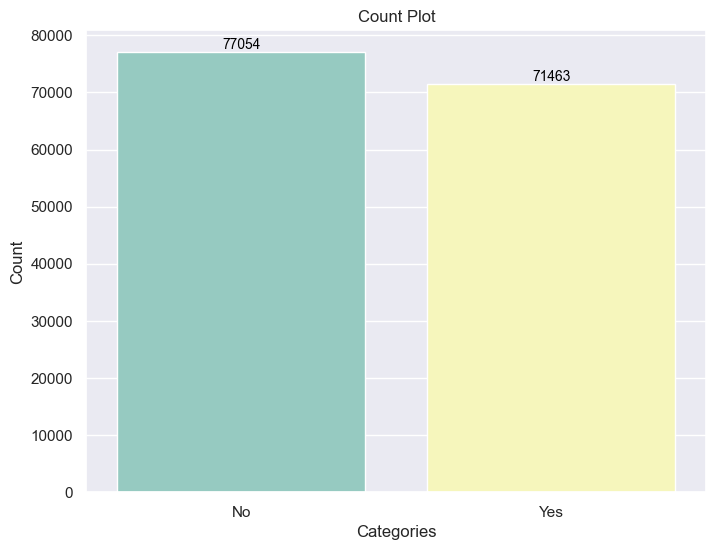

In [9]:
# Create a count plot
sns.set(style="darkgrid")  # Set the style of the plot
plt.figure(figsize=(8, 6))  # Set the figure size
# Replace 'dataset' with your actual DataFrame and 'Drug' with the column name
ax = sns.countplot(x='attack', data=dataset, palette="Set3")
plt.title("Count Plot")  # Add a title to the plot
plt.xlabel("Categories")  # Add label to x-axis
plt.ylabel("Count")  # Add label to y-axis
# Annotate each bar with its count value
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()  # Display the plot

In [10]:
# Converting object type to int type

In [112]:
le= LabelEncoder()
dataset['attack']=  le.fit_transform(dataset['attack'])
dataset['protocol_type']=  le.fit_transform(dataset['protocol_type'])
dataset['service']=  le.fit_transform(dataset['service'])
dataset['flag']=  le.fit_transform(dataset['flag'])

In [113]:
dataset

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,serror_rate,rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,attack
0,0,1,20,9,491,0,0,0,0,0,...,0.0,0.0,1.00,0.00,0.00,150,25,0.17,0.03,0
1,0,2,44,9,146,0,0,0,0,0,...,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60,0
2,0,1,49,5,0,0,0,0,0,0,...,1.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05,1
3,0,1,24,9,232,8153,0,0,0,0,...,0.2,0.0,1.00,0.00,0.00,30,255,1.00,0.00,0
4,0,1,24,9,199,420,0,0,0,0,...,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148512,0,1,54,9,794,333,0,0,0,0,...,0.0,0.0,1.00,0.00,0.00,100,141,0.72,0.06,0
148513,0,1,24,9,317,938,0,0,0,0,...,0.0,0.0,1.00,0.00,0.18,197,255,1.00,0.00,0
148514,0,1,24,9,54540,8314,0,0,0,2,...,0.0,0.0,1.00,0.00,0.20,255,255,1.00,0.00,1
148515,0,2,12,9,42,42,0,0,0,0,...,0.0,0.0,1.00,0.00,0.33,255,252,0.99,0.01,0


In [114]:
#Defining Dependent and independent variables

In [115]:
X=dataset.iloc[:,0:23]

In [116]:
X

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,srv_count,serror_rate,rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate
0,0,1,20,9,491,0,0,0,0,0,...,2,0.0,0.0,1.00,0.00,0.00,150,25,0.17,0.03
1,0,2,44,9,146,0,0,0,0,0,...,1,0.0,0.0,0.08,0.15,0.00,255,1,0.00,0.60
2,0,1,49,5,0,0,0,0,0,0,...,6,1.0,0.0,0.05,0.07,0.00,255,26,0.10,0.05
3,0,1,24,9,232,8153,0,0,0,0,...,5,0.2,0.0,1.00,0.00,0.00,30,255,1.00,0.00
4,0,1,24,9,199,420,0,0,0,0,...,32,0.0,0.0,1.00,0.00,0.09,255,255,1.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148512,0,1,54,9,794,333,0,0,0,0,...,1,0.0,0.0,1.00,0.00,0.00,100,141,0.72,0.06
148513,0,1,24,9,317,938,0,0,0,0,...,11,0.0,0.0,1.00,0.00,0.18,197,255,1.00,0.00
148514,0,1,24,9,54540,8314,0,0,0,2,...,10,0.0,0.0,1.00,0.00,0.20,255,255,1.00,0.00
148515,0,2,12,9,42,42,0,0,0,0,...,6,0.0,0.0,1.00,0.00,0.33,255,252,0.99,0.01


In [117]:
y=dataset.iloc[:,-1]

In [118]:
y

0         0
1         0
2         1
3         0
4         0
         ..
148512    0
148513    0
148514    1
148515    0
148516    1
Name: attack, Length: 148517, dtype: int32

In [119]:
#Datasplitting

In [120]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.20)

In [121]:
X_train.shape

(118813, 23)

In [122]:
X_test.shape

(29704, 23)

In [123]:
#Building a ML Model

In [124]:
labels=['Attack','NORMAL']

In [125]:
#defining global variables to store accuracy and other metrics
precision = []
recall = []
fscore = []
accuracy = []

In [126]:
#function to calculate various metrics such as accuracy, precision etc
def calculateMetrics(algorithm, predict, testY):
    testY = testY.astype('int')
    predict = predict.astype('int')
    p = precision_score(testY, predict,average='macro') * 100
    r = recall_score(testY, predict,average='macro') * 100
    f = f1_score(testY, predict,average='macro') * 100
    a = accuracy_score(testY,predict)*100 
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    print(algorithm+' Accuracy    : '+str(a))
    print(algorithm+' Precision   : '+str(p))
    print(algorithm+' Recall      : '+str(r))
    print(algorithm+' FSCORE      : '+str(f))
    report=classification_report(predict, testY,target_names=labels)
    print('\n',algorithm+" classification report\n",report)
    conf_matrix = confusion_matrix(testY, predict) 
    plt.figure(figsize =(5, 5)) 
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels, annot = True, cmap="Blues" ,fmt ="g");
    ax.set_ylim([0,len(labels)])
    plt.title(algorithm+" Confusion matrix") 
    plt.ylabel('True class') 
    plt.xlabel('Predicted class') 
    plt.show()

# naive bayes Classifier

Model saved successfully.
Naive Bayes Classifier Accuracy    : 51.83140317802316
Naive Bayes Classifier Precision   : 53.65080543865102
Naive Bayes Classifier Recall      : 50.240510032951704
Naive Bayes Classifier FSCORE      : 35.798252789707924

 Naive Bayes Classifier classification report
               precision    recall  f1-score   support

      Attack       0.99      0.52      0.68     29207
      NORMAL       0.02      0.56      0.04       497

    accuracy                           0.52     29704
   macro avg       0.50      0.54      0.36     29704
weighted avg       0.97      0.52      0.67     29704



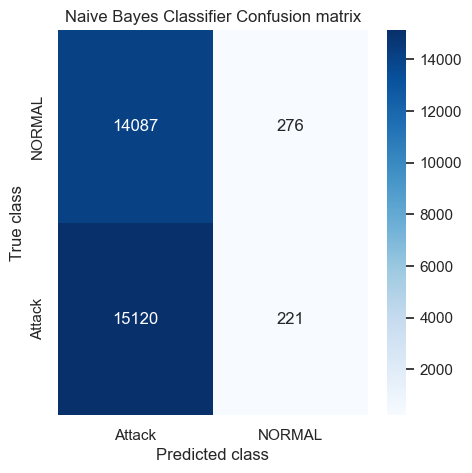

In [127]:
if os.path.exists('naive_bayes_model.pkl'):
    # Load the trained model from the file
    clf = joblib.load('naive_bayes_model.pkl')
    print("Model loaded successfully.")
    predict = clf.predict(X_test)
    calculateMetrics("Naive Bayes Classifier", predict, y_test)
else:
    # Train the model (assuming X_train and y_train are defined)
    clf = GaussianNB()
    clf.fit(X_train, y_train)
    # Save the trained model to a file
    joblib.dump(clf, 'naive_bayes_model.pkl')
    print("Model saved successfully.")
    predict = clf.predict(X_test)
    calculateMetrics("Naive Bayes Classifier", predict, y_test)

# ExtraTreesClassifier

Model saved successfuly.
ExtraTreesClassifier Accuracy    : 99.49165095610019
ExtraTreesClassifier Precision   : 99.4974931469302
ExtraTreesClassifier Recall      : 99.48521822019467
ExtraTreesClassifier FSCORE      : 99.49103779726647

 ExtraTreesClassifier classification report
               precision    recall  f1-score   support

      Attack       1.00      0.99      1.00     15394
      NORMAL       0.99      1.00      0.99     14310

    accuracy                           0.99     29704
   macro avg       0.99      0.99      0.99     29704
weighted avg       0.99      0.99      0.99     29704



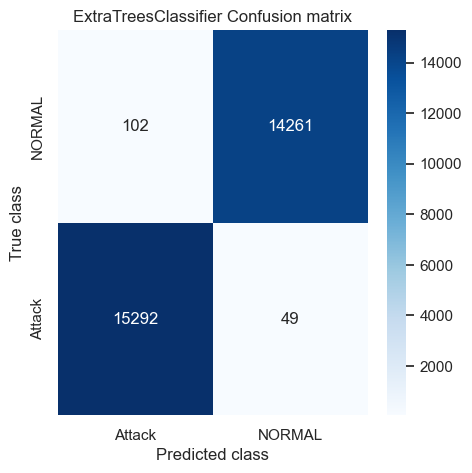

In [128]:
# Check if the model files exist
if os.path.exists('extratrees_model.pkl'):
    # Load the trained model from the file
    clf = joblib.load('extratrees_model.pkl')
    print("Model loaded successfully.")
    predict = clf.predict(X_test)
    calculateMetrics("ExtraTreesClassifier", predict, y_test)
else:
    # Train the model (assuming X_train and y_train are defined)
    clf = ExtraTreesClassifier()
    clf.fit(X_train, y_train)
    # Save the trained model to a file
    joblib.dump(clf, 'extratrees_model.pkl') 
    print("Model saved successfuly.")
    predict = clf.predict(X_test)
    calculateMetrics("ExtraTreesClassifier", predict, y_test)

In [129]:
#Performance Comparision of both the algorithmns

In [130]:
#showing all algorithms performance values
columns = ["Algorithm Name","Precison","Recall","FScore","Accuracy"]
values = []
algorithm_names = ["Naive Bayes Classifier", "ExtraTreesClassifier"]
for i in range(len(algorithm_names)):
    values.append([algorithm_names[i],precision[i],recall[i],fscore[i],accuracy[i]])
    
temp = pd.DataFrame(values,columns=columns)
temp

,Algorithm Name,Precison,Recall,FScore,Accuracy
0,Naive Bayes Classifier,53.650805,50.240510,35.798253,51.831403
1,ExtraTreesClassifier,99.497493,99.485218,99.491038,99.491651


In [131]:
# prediction

In [132]:
dataset=pd.read_csv("test.csv")

In [133]:
dataset

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,srv_count,serror_rate,rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,2,0.0,0,1.00,0.00,0.00,150,25,0.17,0.03
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.0,0,0.08,0.15,0.00,255,1,0.00,0.60
2,0,tcp,private,S0,0,0,0,0,0,0,...,6,1.0,0,0.05,0.07,0.00,255,26,0.10,0.05
3,0,tcp,http,SF,232,8153,0,0,0,0,...,5,0.2,0,1.00,0.00,0.00,30,255,1.00,0.00
4,0,tcp,http,SF,199,420,0,0,0,0,...,32,0.0,0,1.00,0.00,0.09,255,255,1.00,0.00
5,0,tcp,private,REJ,0,0,0,0,0,0,...,19,0.0,1,0.16,0.06,0.00,255,19,0.07,0.07
6,0,tcp,private,S0,0,0,0,0,0,0,...,9,1.0,0,0.05,0.06,0.00,255,9,0.04,0.05
7,0,tcp,http,SF,287,2251,0,0,0,0,...,7,0.0,0,1.00,0.00,0.43,8,219,1.00,0.00
8,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,2,0.0,0,1.00,0.00,0.00,2,20,1.00,0.00
9,0,tcp,name,S0,0,0,0,0,0,0,...,1,1.0,0,0.00,0.06,0.00,255,1,0.00,0.07


In [134]:
dataset['protocol_type']=  le.fit_transform(dataset['protocol_type'])
dataset['service']=  le.fit_transform(dataset['service'])
dataset['flag']=  le.fit_transform(dataset['flag'])

# Make predictions on the selected test data
predict = clf.predict(dataset)

# Loop through each prediction and print the corresponding row
for i, p in enumerate(predict):
    if p == 0:
        print(dataset.iloc[i])  # Print the row where prediction is failure
        print("Row {}:************************************************** Attack".format(i))
        
    else:
        print(dataset.iloc[i])  # Print the row where prediction is no failure
        print("Row {}:************************************************** NORMAL".format(i))
        


duration                    0.00
protocol_type               1.00
service                     1.00
flag                        2.00
src_bytes                 491.00
dst_bytes                   0.00
land                        0.00
wrong_fragment              0.00
urgent                      0.00
hot                         0.00
logged_in                   0.00
num_compromised             0.00
count                       2.00
srv_count                   2.00
serror_rate                 0.00
rerror_rate                 0.00
same_srv_rate               1.00
diff_srv_rate               0.00
srv_diff_host_rate          0.00
dst_host_count            150.00
dst_host_srv_count         25.00
dst_host_same_srv_rate      0.17
dst_host_diff_srv_rate      0.03
Name: 0, dtype: float64
Row 0:************************************************** Attack
duration                    0.00
protocol_type               2.00
service                     6.00
flag                        2.00
src_bytes            

In [136]:
dataset['Predicted']=predict

In [137]:
dataset

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,serror_rate,rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,Predicted
0,0,1,1,2,491,0,0,0,0,0,...,0.0,0,1.00,0.00,0.00,150,25,0.17,0.03,0
1,0,2,6,2,146,0,0,0,0,0,...,0.0,0,0.08,0.15,0.00,255,1,0.00,0.60,1
2,0,1,7,1,0,0,0,0,0,0,...,1.0,0,0.05,0.07,0.00,255,26,0.10,0.05,1
3,0,1,2,2,232,8153,0,0,0,0,...,0.2,0,1.00,0.00,0.00,30,255,1.00,0.00,0
4,0,1,2,2,199,420,0,0,0,0,...,0.0,0,1.00,0.00,0.09,255,255,1.00,0.00,0
5,0,1,7,0,0,0,0,0,0,0,...,0.0,1,0.16,0.06,0.00,255,19,0.07,0.07,1
6,0,1,7,1,0,0,0,0,0,0,...,1.0,0,0.05,0.06,0.00,255,9,0.04,0.05,1
7,0,1,2,2,287,2251,0,0,0,0,...,0.0,0,1.00,0.00,0.43,8,219,1.00,0.00,0
8,0,1,1,2,334,0,0,0,0,0,...,0.0,0,1.00,0.00,0.00,2,20,1.00,0.00,0
9,0,1,4,1,0,0,0,0,0,0,...,1.0,0,0.00,0.06,0.00,255,1,0.00,0.07,1
